In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np


# ..............................................................
#
class VisualDomain:
    def __init__(self, 
                 start, 
                 end, 
                 label="", 
                 label_rotation=0,
                 label_fontsize=6,
                 label_ha="center",  # horizontal alignment
                 label_va="center",  # vertical alignment
                 label_x_offset=0,
                 label_y_offset=0,
                 color="skyblue", 
                 width=0.6, 
                 alpha=0.8,
                 edge_color='black',
                 edge_width=0.5,
                 horizontal_band_color=None,
                 horizontal_band_alpha=0.2,
                 horizontal_band_zorder=0):        
        """
        Visual representation of a protein domain for plotting. Parameters
        with a label_ prefix control the appearance and positioning of the
        domain label. Other parameters control the visual style of the domain
        rectangle.

        Parameters:
        ---------------
        start : int
            Start position of the domain (1-based).

        end : int
            End position of the domain (1-based).

        label : str
            Optional label for the domain.

        label_rotation : float
            Rotation angle for the label text. Default is 0 
            (horizontal).

        label_fontsize : int
            Font size for the label text.       

        label_ha : str
            Horizontal alignment for the label text 
            ('left', 'center', 'right').

        horizontal_band_color : str
            Color for horizontal band highlighting (if any). If
            provided, a horizontal band will be drawn across the
            entire plot at the domain's position.

        horizontal_band_alpha : float
            Transparency for the horizontal band (0 to 1). Default
            is 0.2.

        """

        if start < 1 or end < start:
            raise ValueError("Invalid domain start/end positions.")
        
        if width <= 0:
            raise ValueError("Width must be positive.")
        
        if alpha < 0 or alpha > 1:
            raise ValueError("Alpha must be between 0 and 1.")
        
        if edge_width < 0:
            raise ValueError("Edge width must be non-negative.")
        
        if label_ha not in ['left', 'center', 'right']:
            raise ValueError("label_ha must be 'left', 'center', or 'right'.")
        
        if label_va not in ['top', 'center', 'bottom']:
            raise ValueError("label_va must be 'top', 'center', or 'bottom'.")  
        
        if not isinstance(label_fontsize, (int, float)) or label_fontsize <= 0:
            raise ValueError("label_fontsize must be a positive number.")
        
        if not isinstance(label_rotation, (int, float)):
            raise ValueError("label_rotation must be a number.")
        
        if not isinstance(label_x_offset, (int, float)):
            raise ValueError("label_x_offset must be a number.")
        
        if not isinstance(label_y_offset, (int, float)):
            raise ValueError("label_y_offset must be a number.")
        
        if color is not None and not isinstance(color, str):
            raise ValueError("color must be a string representing a color.")
        
        if horizontal_band_alpha < 0 or horizontal_band_alpha > 1:
            raise ValueError("horizontal_band_alpha must be between 0 and 1.")
        
        if horizontal_band_color is not None and not isinstance(horizontal_band_color, str):
            raise ValueError("horizontal_band_color must be a string representing a color.")
        
        if horizontal_band_zorder is not None and not isinstance(horizontal_band_zorder, int):
            raise ValueError("horizontal_band_zorder must be an integer.")
                
        # domain position
        self.start = start
        self.end = end

        # domain visual params
        self.color       = color       # Domain-specific color
        self.width       = width       # Domain-specific width
        self.alpha       = alpha       # Domain-specific transparency
        self.edge_color  = edge_color  # Domain-specific edge color
        self.edge_width  = edge_width  # Domain-specific edge width

        # label params
        self.label = label
        self.label_rotation = label_rotation 
        self.label_fontsize = label_fontsize
        self.label_ha = label_ha  # horizontal alignment
        self.label_va = label_va  # vertical alignment  
        self.label_x_offset = label_x_offset
        self.label_y_offset = label_y_offset    

        # horizontal band params
        self.horizontal_band_color = horizontal_band_color
        self.horizontal_band_alpha = horizontal_band_alpha
        self.horizontal_band_zorder = horizontal_band_zorder


# ..............................................................
#
class DomainTrack:
    def __init__(self, name, track_width=1.0):
        """
        Track for plotting protein domains along the sequence. Domains are represented
        as colored rectangles with optional labels, and a domain track can contain multiple
        non-overlapping domains.

        Parameters:
        ---------------
        name : str
            Name of the domain track.

        Methods:
        ---------------
        add_domain(start, end, **kwargs):
            Adds a domain to the track with specified start and end positions and visual parameters.

        Raises:
        ---------------
        ValueError:
            If the new domain overlaps with any existing domains in the track.
        """
        self.name = name
        self.track_width = track_width
        self.features = []




    def add_domain(self, start, end, **kwargs):
        """
        Adds a domain to the track.

        Parameters:
        ---------------
        start : int
            Start position of the domain (1-based).

        end : int
            End position of the domain (1-based).

        kwargs : dict
            Additional visual parameters for the domain (see VisualDomain).

        Raises:
        ---------------
        ValueError:
            If the new domain overlaps with any existing domains in the track.

        """

        # check if the start and end values overlap with an existing domain
        for dom in self.features:
            if not (end < dom.start or start > dom.end):
                raise ValueError(f"Domain ({start}, {end}) overlaps with existing domain ({dom.start}, {dom.end})")
            
        self.features.append(VisualDomain(start, end, **kwargs))

# ..............................................................
#
class LinearTrack:
    def __init__(self, 
                 name, 
                 values, 
                 plot_type='line',
                 color='blue',
                 track_width = 1.0,
                 line_width = 1.5,
                 bar_height = 1.0):
        
        """
        Linear track for plotting continuous data along the protein sequence. Linear
        tracks can be rendered as line plots or bar plots and are scaled to fit within 
        a specified track width.

        Parameters:
        ---------------
        name : str
            Name of the track.

        values : list or np.ndarray
            Continuous values for each residue position.

        plot_type : str
            Type of plot: 'line' or 'bar'.

        color : str
            Color of the plot.

        track_width : float
            Width of the track in the plot.

        line_width : float
            Line width for line plots. Ignored for bar plots.

        bar_height : float
            Bar height for bar plots. Ignored for line plots.
        
        """
        
        # sanity checks
        if plot_type not in ['line', 'bar']:
            raise ValueError("plot_type must be 'line' or 'bar'")
        
        if plot_type == 'line' and line_width <= 0:
            raise ValueError("line_width must be positive for line plots")
        
        if plot_type == 'bar' and bar_height <= 0:
            raise ValueError("bar_height must be positive for bar plots")
    
        if not isinstance(values, (list, np.ndarray)):
            raise ValueError("values must be a list or numpy array")
        
        if len(values) == 0:
            raise ValueError("values cannot be empty")
        
        self.name = name
        self.values = np.array(values)
        self.plot_type = plot_type # 'line' or 'bar'
        self.color = color
        self.track_width = track_width        
        self.line_width = line_width          # for line plots
        self.bar_height = bar_height           # for bar plots

# ..............................................................
#
class GridTrack:
    def __init__(self, 
                 name, 
                 data, 
                 colormaps=None, 
                 v_limits=None,
                 track_width=1.0,
                 column_names=None,
                 column_label_fontsize=5,
                 column_label_y_offset=-2):
        """
        data: np.ndarray of shape (n_residues, n_columns)
        colormaps: list of strings (e.g., ['Reds', 'Blues']) length must match n_columns
        """
        self.name = name
        self.values = np.array(data)
        self.n_res, self.n_cols = self.values.shape
        self.track_width = track_width
        self.column_names = column_names
        self.column_label_fontsize = column_label_fontsize
        self.column_label_y_offset = column_label_y_offset
        self.v_limits = v_limits # Store the custom limits
        
        # Default to 'Viridis' if no colormaps provided
        if colormaps is None:
            self.colormaps = ['viridis'] * self.n_cols
        else:
            self.colormaps = colormaps        


# ..............................................................
#
class SequenceDomain:
    def __init__(self, 
                 name,                  
                 start,
                 end):

        """
        Domain for holding sequence information

        Parameters:
        ---------------

        name : str
            Name of the sequence track.

        sequence : str
            Amino acid sequence of the protein.
            
        start_res : int
            Starting residue number for the sequence (default: 1).
        """
        self.name = name        
        self.start_res = start
        self.end_res = end


class SequenceTrack:
    def __init__(self, 
                 sequence,
                 name,
                 aa_colors=None, 
                 fontsize=6, 
                 track_width=1.0,
                 chars_per_block=10,
                 blocks_per_row=2):                 
        """
        Track for displaying the amino acid sequence of a protein along its length.

        Parameters:
        ---------------
        
        sequence : str
            Amino acid sequence of the protein.

        aa_colors : dict
            Optional dictionary mapping amino acids to colors.

        fontsize : int
            Font size for the sequence characters.

        track_width : float
            Width of the track in the plot.
        
        chars_per_block : int
            Number of characters to display per block.

        blocks_per_row : int
            Number of blocks to display per row.
        
    
        """
        self.sequence        = sequence
        self.name            = name
        self.aa_colors       = aa_colors if aa_colors else {}
        self.fontsize        = fontsize
        self.track_width     = track_width
        self.chars_per_block = chars_per_block
        self.blocks_per_row  = blocks_per_row
        self.features        = []


    def add_domain(self, sequence_domain):
        """
        Adds a SequenceDomain to the track.

        Parameters:
        ---------------
        sequence_domain : SequenceDomain
            SequenceDomain object containing sequence information.
        """

        if sequence_domain.end_res > len(self.sequence):
            raise ValueError("SequenceDomain end_res exceeds sequence length.")
        
        if sequence_domain.start_res < 1:
            raise ValueError("SequenceDomain start_res must be >= 1.")  
        
        for existing_domain in self.features:
            if not (sequence_domain.end_res < existing_domain.start_res or 
                    sequence_domain.start_res > existing_domain.end_res):
                raise ValueError(f"SequenceDomain ({sequence_domain.start_res}, {sequence_domain.end_res}) overlaps with existing domain ({existing_domain.start_res}, {existing_domain.end_res})")

        self.features.append(sequence_domain)
        
# ..............................................................
#
class VisualProtein:
    """Container for a single protein's sequence data and tracks."""
    def __init__(self, 
                 name, 
                 length=None,    
                 sequence=None,             
                 backbone_color='black', 
                 backbone_width=1.0, 
                 backbone_zorder=1): 
        """
        Visual representation of a protein for plotting. Can contain
        multiple tracks (DomainTrack, LinearTrack, GridTrack) and 
        visual parameters for the protein backbone.
        
        Parameters:
        ---------------

        name : str
            Name of the protein.

        length : int, optional.
            Length of the protein sequence (number of residues),
            optional if sequence is provided. 
        
        sequence : str, optional
            Amino acid sequence of the protein (optional, but if
            provided, length of string must match length).

        backbone_color : str
            Color of the protein backbone line in the plot.

        backbone_width : float
            Width of the protein backbone line in the plot.

        backbone_zorder : int
            Z-order for the protein backbone line in the plot.
        """

        self.name = name

        if sequence is not None:
            if not isinstance(sequence, str):
                raise ValueError("sequence must be a string")
            if length is not None and length != len(sequence):
                raise ValueError("Provided length does not match length of sequence")
            self.sequence = sequence
            self.length = len(sequence)
        elif length is not None:
            if not isinstance(length, int) or length <= 0:
                raise ValueError("length must be a positive integer")
            self.length = length
            self.sequence = None
        else:
            raise ValueError("Either length or sequence must be provided")
        
        self.tracks = []
        self.backbone_color  = backbone_color
        self.backbone_width  = backbone_width
        self.backbone_zorder = backbone_zorder

    def add_track(self, track):
        """
        Adds a track (DomainTrack, LinearTrack, or GridTrack) to the protein.

        Parameters:
        ---------------
        track : DomainTrack, LinearTrack, or GridTrack
            Track object to add to the protein.

        Raises:
        ---------------
        ValueError:
            If the track's data length does not match the protein length.

        """

        # sanity checks
        if isinstance(track, DomainTrack):
            for domain in track.features:
                if domain.start < 1 or domain.end > self.length:
                    raise ValueError(f"Domain ({domain.start}, {domain.end}) is out of bounds for protein length {self.length}")    
        
        elif isinstance(track, LinearTrack):
            if len(track.values) != self.length:
                raise ValueError(f"Length of LinearTrack values ({len(track.values)}) does not match protein length ({self.length})")
            
        elif isinstance(track, GridTrack):
            if track.n_res != self.length:
                raise ValueError(f"Number of residues in GridTrack ({track.n_res}) does not match protein length ({self.length})")
            
        elif isinstance(track, SequenceTrack):
            if len(track.features) == 0:
                raise ValueError("SequenceTrack must contain at least one SequenceDomain")
            if len(track.sequence) != self.length:
                raise ValueError(f"Length of SequenceTrack sequence ({len(track.sequence)}) does not match protein length ({self.length})")
        else:
            raise ValueError("track_obj must be an instance of DomainTrack, LinearTrack, or GridTrack")

        self.tracks.append(track)


# ..............................................................
#
def plot_protein_structure(proteins, horiontal_bands=None, **kwargs):
    """
    Stateless function to plot one or more VisualProtein objects.

    Parameters:
    ---------------
    proteins : VisualProtein or list of VisualProtein
        Single VisualProtein object or a list of VisualProtein objects 
        to plot.

    horiontal_bands : list of tuples
        List of (start, end, color, alpha) tuples defining horizontal bands 
        to highlight specific residue ranges across all tracks.

    kwargs : dict
        Additional configuration options for the plot. 
        Options here are:

        spacing : float
            Horizontal distance between tracks (default: 1.0).

        figsize : tuple
            Figure size (width, height). This can be passed but 
            we strongly recommend allowing the function to auto-scale
            the width based on number of proteins.

        dpi : int
            Dots per inch for the figure (default: 350).

        show_grid : bool
            Whether to show grid lines (default: True).

        tick_label_size : int
            Font size for tick labels.

        width_scale_factor : float
            Scaling factor for figure width based on number of 
            proteins (default: 2.5).

        figure_height : float
            Height of the figure (default: 10).

        font_size : int
            Default font size for labels (default: 5).

        show_guidelines : bool
            Over-ride for whether to show guideline lines for tracks (default: True).
        
    Returns:
    ---------------
    fig, ax : matplotlib Figure and Axes objects
        The created matplotlib figure and axes.
    """
    if not isinstance(proteins, list):
        proteins = [proteins]

    # Config options

    # defines a scale factor for figure width based on number of proteins;
    # this is only used if figsize is not explicitly provided
    _width_scale_factor = kwargs.get('width_scale_factor', 2.5)

    # defines the figure height; default is 10, this is 
    # only used if figsize is not explicitly provided
    _figure_height = kwargs.get('figure_height', 10)
    
    # defines the spacing between tracks
    spacing = kwargs.get('spacing', 1.0)

    # default font size for all labels - useful if you 
    # play with the dpi and figure size
    default_fontsize = kwargs.get('font_size', 5)

    # if this gets set to None, we use the track-defined
    # flags, otherwise we over-ride those flags with this
    # as a master over-ride
    show_guidelines = kwargs.get('show_guidelines', None)

    # build the figure size either from kwargs or auto-scale
    figsize = kwargs.get('figsize', (len(proteins) * _width_scale_factor, _figure_height))

    # set the dpi
    dpi = kwargs.get('dpi', 350)

    # flag if we show grid lines
    show_grid = kwargs.get('show_grid', True)

    ## ..................................................... 
    ## Create the figure and axis
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

            

    spine_width = kwargs.get('spine_width', 1.0)
    for spine in ax.spines.values():
        spine.set_linewidth(spine_width)    

    tick_width = kwargs.get('tick_width', spine_width)
    tick_length = kwargs.get('tick_length', 2.0)
    ax.tick_params(axis='both', 
                   width=tick_width, 
                   length=tick_length, 
                   direction=kwargs.get('tick_direction', 'out'))        
    
    current_x_offset = 0.0
    track_labels = []
    track_positions = []

    if show_guidelines:
        guideline_color = 'k'
        guideline_width = 0.25
    else:
        guideline_color = 'w'
        guideline_width = 0.01

    for protein in proteins:

        # for each track
        for track in protein.tracks:

            local_track_width = getattr(track, 'track_width', 0.6)

            current_x_offset += (local_track_width * 0.5)
            
            x_center = current_x_offset
            track_positions.append(x_center)

            if isinstance(track, GridTrack):
                track_labels.append("")
            else:
                track_labels.append(f"{protein.name}\n({track.name})")

            # --- Render DomainTrack ---
            if isinstance(track, DomainTrack):
                
                # first plot the backbone
                ax.plot([x_center, x_center], [1, protein.length], 
                        color=protein.backbone_color, 
                        lw=protein.backbone_width, 
                        zorder=protein.backbone_zorder)
                
                for dom in track.features:
                    # Use the specific width defined in the VisualDomain object
                    rect = patches.Rectangle(
                        (x_center - dom.width/2, dom.start),
                        dom.width,
                        dom.end - dom.start,
                        facecolor = dom.color, 
                        edgecolor = dom.edge_color, 
                        linewidth = dom.edge_width,
                        alpha = dom.alpha, 
                        zorder = 2
                    )
                    ax.add_patch(rect)

                    if dom.label:
                        ax.text(x_center + dom.label_x_offset, 
                                (dom.start + dom.end)/2 + dom.label_y_offset, 
                                dom.label, 
                                ha = dom.label_ha, 
                                va = dom.label_va, 
                                rotation = dom.label_rotation,
                                fontsize = dom.label_fontsize)
                        
                    if dom.horizontal_band_color is not None:
                        ax.axhspan(dom.start, dom.end, 
                                   color=dom.horizontal_band_color, 
                                   alpha=dom.horizontal_band_alpha, 
                                   zorder=dom.horizontal_band_zorder, lw=0)

            # --- Render LinearTrack ---
            elif isinstance(track, LinearTrack):
                v_min, v_max = track.values.min(), track.values.max()
                v_range = (v_max - v_min) if v_max != v_min else 1
                
                # Rescale data to track_width
                norm_data = ((track.values - v_min) / v_range - 0.5) * track.track_width
                y_coords = np.arange(1, len(track.values) + 1)
                x_coords = x_center + norm_data

                if track.plot_type == 'line':
                    ax.plot(x_coords, y_coords, color=track.color, lw=track.line_width)
                else:
                    ax.barh(y_coords, norm_data, left=x_center, color=track.color, height=track.bar_height)
                
            # --- Render GridTrack ---
            elif isinstance(track, GridTrack):
                col_width = track.track_width / track.n_cols
                y_coords = np.arange(1, track.n_res + 1)
                
                for c in range(track.n_cols):
                    # Calculate x boundaries for this specific column
                    x_start = (x_center - track.track_width/2) + (c * col_width)
                    x_end = x_start + col_width
                    
                    # Normalize data for this column to [0, 1] for the colormap
                    col_data = track.values[:, c]
                    
                    # --- Scaling Logic --- if we passed limits use them,
                    # else scale between min and max of the data
                    if track.v_limits and len(track.v_limits) > c:
                        v_min, v_max = track.v_limits[c]
                    else:
                        v_min, v_max = col_data.min(), col_data.max()

                    v_range = v_max - v_min if v_max != v_min else 1
                    norm_scores = (col_data - v_min) / v_range
                    
                    # Get the colormap
                    cmap = plt.get_cmap(track.colormaps[c])
                    colors = cmap(norm_scores)
                    
                    # Draw the column using horizontal segments
                    # We use barh with a height of 1.0 to create a seamless heatmap
                    ax.barh(y_coords, [col_width] * len(y_coords), 
                            left=x_start, color=colors, height=1.0, edgecolor='none')
                    
                    # Optional: Add column sub-labels at the top
                    if track.column_names:
                        ax.text((x_start + x_end)/2, track.column_label_y_offset, track.column_names[c], 
                                ha='center', va='bottom', fontsize=track.column_label_fontsize, rotation=90)

            # --- Render SequenceTrack (Block-Aligned) ---
            elif isinstance(track, SequenceTrack):
                chars_per_row = track.chars_per_block * track.blocks_per_row
                
                for d in track.features:
                    local_sequence = track.sequence[d.start_res - 1 : d.end_res]
                
                    for i, char in enumerate(local_sequence):
                        
                        # 1. Determine which row and column this character belongs to
                        row_index = i // chars_per_row
                        col_index = i % chars_per_row
                        block_index = col_index // track.chars_per_block
                        
                        # 2. X-Position Calculation
                        # Distribute characters across the track width
                        total_units = chars_per_row + (track.blocks_per_row - 1) * 0.5
                        x_step = track.track_width / total_units

                        #x_step = track.track_width / (chars_per_row + (track.blocks_per_row - 1))
                        x_pos = (x_center - track.track_width/2) + \
                                (x_step * 0.5) + \
                                (col_index * x_step) + \
                                (block_index * (x_step * 0.5))
                     
                        # 3. Y-Position Calculation 
                        # Center the text row in the middle of the residue range it represents
                        # e.g., if chars_per_row is 20, row 0 is centered at start + 10
                        y_row_center = d.start_res + (row_index * chars_per_row) + (chars_per_row / 2)
                        
                        # 4. Color and Plot
                        color = track.aa_colors.get(char, 'black')
                        
                        ax.text(x_pos, y_row_center, char, 
                                color=color, 
                                fontsize=track.fontsize, 
                                fontfamily='monospace',                                
                                va='center', ha='center')

            # Visual Guide: Draw a faint box or line showing the sequence range
            ax.axvline(x_center - track.track_width/2, color=guideline_color, lw=guideline_width, ls='--')
            ax.axvline(x_center + track.track_width/2, color=guideline_color, lw=guideline_width, ls='--')

            current_x_offset += spacing + (local_track_width * 0.5)

    # Highlight horizontal bands if provided
    if horiontal_bands is not None:
        try: 
            for (start_, end_, color_, alpha_) in horiontal_bands:
                ax.axhspan(start_, end_, color=color_, alpha=alpha_, zorder=0, lw=0)
        except Exception as e:
            raise ValueError("horiontal_bands must be a list of (start, end, color, alpha) tuples") from e

    # Global Styling
    max_len = max(p.length for p in proteins)
    ax.set_ylim(max_len + 10, -10) # Residue 1 at top
    ax.set_xticks(track_positions)
    
    ax.set_xticklabels(track_labels, fontsize=kwargs.get('tick_label_size', default_fontsize))
    ax.xaxis.tick_top()

    ax.tick_params(axis='y', labelsize=kwargs.get('tick_label_size', default_fontsize))
    ax.set_ylabel("Residue Position", fontsize=kwargs.get('tick_label_size', default_fontsize))
        
    if show_grid:
        ax.grid(axis='y', linestyle=':', alpha=0.6)
    
    plt.tight_layout()
    return fig, ax        

(<Figure size 875x1225 with 1 Axes>, <Axes: ylabel='Residue Position'>)

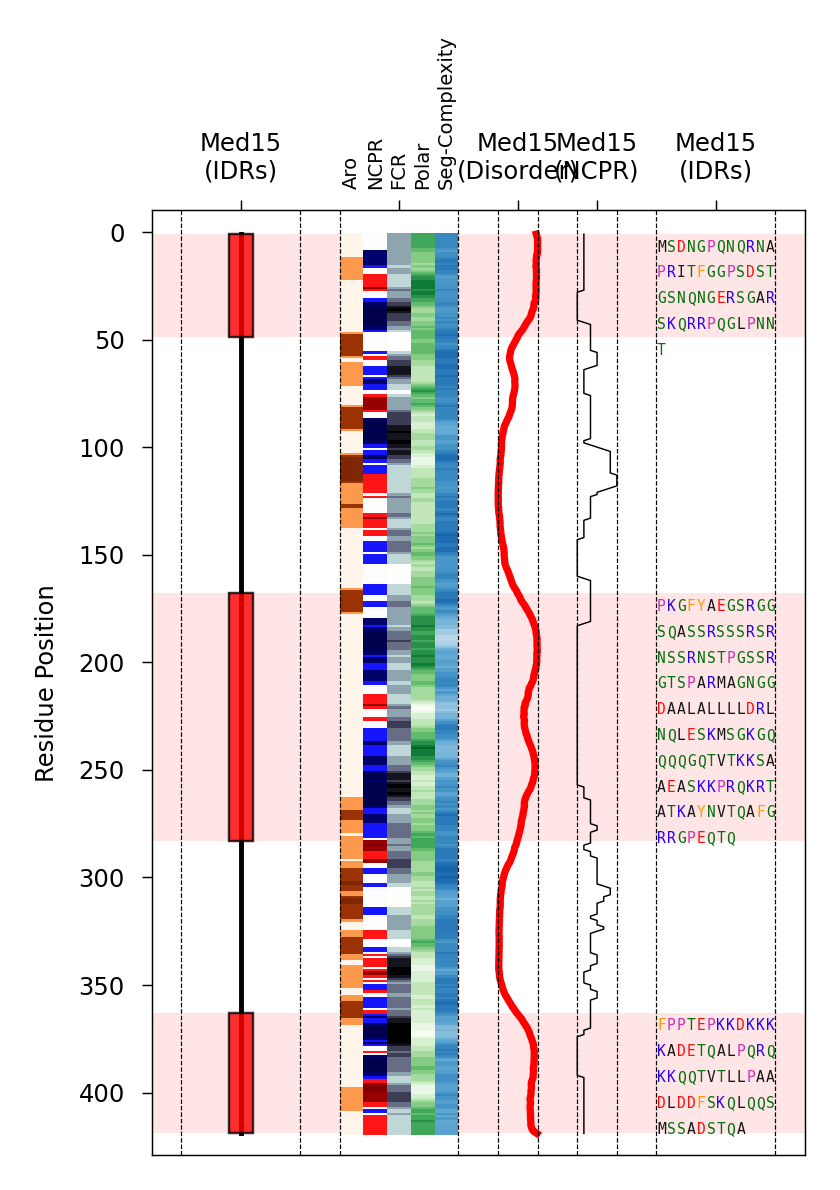

In [302]:
from sparrow.data.amino_acids import AA_COLOR
from sparrow import Protein
import metapredict as meta


seq = 'MSAAPVQDKDTLSNAERAKNVNGLLQVLMDINTLNGGSSDTADKIRIHAKNFEAALFAKSSSKKEYMDSMNEKVAVMRNTYNTRKNAVTAAAANNNIKPVEQHHINNLKNSGNSANNMNVNMNLNPQMFLNQQAQARQQVAQQLRNQQQQQQQQQQQQRRQLTPQQQQLVNQMKVAPIPKQLLQRIPNIPPNINTWQQVTALAQQKLLTPQDMEAAKEVYKIHQQLLFKARLQQQQAQAQAQANNNNNGLPQNGNINNNINIPQQQQMQPPNSSANNNPLQQQSSQNTVPNVLNQINQIFSPEEQRSLLQEAIETCKNFEKTQLGSTMTEPVKQSFIRKYINQKALRKIQALRDVKNNNNANNNGSNLQRAQNVPMNIIQQQQQQNTNNNDTIATSATPNAAAFSQQQNASSKLYQMQQQQQAQAQAQAQAQAQAQAQAQAQAAQAAQAQAQAQAQAQAQAQAQAQAQAQAQAQAQAQAQAHAQHQPSQQPQQAQQQPNPLHGLTPTAKDVEVIKQLSLDASKTNLRLTDVTNSLSNEEKEKIKMKLKQGQKLFVQVSNFAPQVYIITKNENFLKEVFQLRIFVKEILEKCAEGIFVVKLDTVDRLIIKYQKYWESMRIQILRRQAILRQQQQMANNNGNPGTTSTGNNNNIATQQNMQQSLQQMQHLQQLKMQQQQQQQQQQQQQQQQQQQQQQQHIYPSSTPGVANYSAMANAPGNNIPYMNHKNTSSMDFLNSMENTPKVPVSAAATPSLNKTINGKVNGRTKSNTIPVTSIPSTNKKLSISNAASQQPTPRSASNTAKSTPNTNPSPLKTQTKNGTPNPNNMKTVQSPMGAQPSYNSAIIENAFRKEELLLKDLEIRKLEISSRFKHRQEIFKDSPMDLFMSTLGDCLGIKDEEMLTSCTIPKAVVDHINGSGKRKPTKAAQRARDQDSIDISIKDNKLVMKSKFNKSNRSYSIALSNVAAIFKGIGGNFKDLSTLVHSSSPSTSSNMDVGNPRKRKASVLEISPQDSIASVLSPDSNIMSDSKKIKVDSPDDPFMTKSGATTSEKQEVTNEAPFLTSGTSSEQFNVWDWNNWTSAT'
seq = 'MSKSESPKEPEQLRKLFIGGLSFETTDESLRSHFEQWGTLTDCVVMRDPNTKRSRGFGFVTYATVEEVDAAMNARPHKVDGRVVEPKRAVSREDSQRPGAHLTVKKIFVGGIKEDTEEHHLRDYFEQYGKIEVIEIMTDRGSGKKRGFAFVTFDDHDSVDKIVIQKYHTVNGHNCEVRKALSKQEMASASSSQRGRSGSGNFGGGRGGGFGGNDNFGRGGNFSGRGGFGGSRGGGGYGGSGDGYNGFGNDGGYGGGGPGYSGGSRGYGSGGQGYGNQGSGYGGSGSYDSYNNGGGGGFGGGSGSNFGGGGSYNDFGNYNNQSSNFGPMKGGNFGGRSSGPYGGGGQYFAKPRNQGGYGGSSSSSSYGSGRRF'
#seq = 'MKAQGETEESEKLSKMSSLLERLHAKFNQNRPWSETIKLVRQVMEKRVVMSSGGHQHLVSCLETLQKALKVTSLPAMTDRLESIARQNGLGSHLSASGTECYITSDMFYVEVQLDPAGQLCDVKVAHHGENPVSCPELVQQLREKNFDEFSKHLKGLVNLYNLPGDNKLKTKMYLALQSLEQDLSKMAIMYWKATNAGPLDKILHGSVGYLTPRSGGHLMNLKYYVSPSDLLDDKTASPIILHENNVSRSLGMNASVTIEGTSAVYKLPIAPLIMGSHPVDNKWTPSFSSITSANSVDLPACFFLKFPQPIPVSRAFVQKLQNCTGIPLFETQPTYAPLYELITQFELSKDPDPIPLNHNMRFYAALPGQQHCYFLNKDAPLPDGRSLQGTLVSKITFQHPGRVPLILNLIRHQVAYNTLIGSCVKRTILKEDSPGLLQFEVCPLSESRFSVSFQHPVNDSLVCVVMDVQDSTHVSCKLYKGLSDALICTDDFIAKVVQRCMSIPVTMRAIRRKAETIQADTPALSLIAETVEDMVKKNLPPASSPGYGMTTGNNPMSGTTTPTNTFPGGPITTLFNMSMSIKDRHESVGHGEDFSKVSQNPILTSLLQITGNGGSTIGSSPTPPHHTPPPVSSMAGNTKNHPMLMNLLKDNPAQDFSTLYGSSPLERQNSSSGSPRMEICSGSNKTKKKKSSRLPPEKPKHQTEDDFQRELFSMDVDSQNPIFDVNMTADTLDTPHITPAPSQCSTPPTTYPQPVPHPQPSIQRMVRLSSSDSIGPDVTDILSDIAEEASKLPSTSDDCPAIGTPLRDSSSSGHSQSTLFDSDVFQTNNNENPYTDPADLIADAAGSPSSDSPTNHFFHDGVDFNPDLLNSQSQSGFGEEYFDESSQSGDNDDFKGFASQALNTLGVPMLGGDNGETKFKGNNQADTVDFSIISVAGKALAPADLMEHHSGSQGPLLTTGDLGKEKTQKRVKEGNGTSNSTLSGPGLDSKPGKRSRTPSNDGKSKDKPPKRKKADTEGKSPSHSSSNRPFTPPTSTGGSKSPGSAGRSQTPPGVATPPIPKITIQIPKGTVMVGKPSSHSQYTSSGSVSSSGSKSHHSHSSSSSSSASTSGKMKSSKSEGSSSSKLSSSMYSSQGSSGSSQSKNSSQSGGKPGSSPITKHGLSSGSSSTKMKPQGKPSSLMNPSLSKPNISPSHSRPPGGSDKLASPMKPVPGTPPSSKAKSPISSGSGGSHMSGTSSSSGMKSSSGLGSSGSLSQKTPPSSNSCTASSSSFSSSGSSMSSSQNQHGSSKGKSPSRNKKPSLTAVIDKLKHGVVTSGPGGEDPLDGQMGVSTNSSSHPMSSKHNMSGGEFQGKREKSDKDKSKVSTSGSSVDSSKKTSESKNVGSTGVAKIIISKHDGGSPSIKAKVTLQKPGESSGEGLRPQMASSKNYGSPLISGSTPKHERGSPSHSKSPAYTPQNLDSESESGSSIAEKSYQNSPSSDDGIRPLPEYSTEKHKKHKKEKKKVKDKDRDRDRDKDRDKKKSHSIKPESWSKSPISSDQSLSMTSNTILSADRPSRLSPDFMIGEEDDDLMDVALIGN'
seq = "MSDSNQGNNQQNYQQYSQNGNQQQGNNRYQGYQAYNAQAQPAGGYYQNYQGYSGYQQGGYQQYNPDAGYQQQYNPQGGYQQYNPQGGYQQQFNPQGGRGNYKNFNYNNNLQGYQAGFQPQSQGMSLNDFQKQQKQAAPKPKKTLKLVSSSGIKLANATKKVGTKPAESDKKEEEKSAETKEPTKEPTKVEEPVKKEEKPVQTEEKTEEKSELPKVEDLKISESTHNTNNANVTSADALIKEQEEEVDDEVVNDMFGGKDHVSLIFMGHVDAGKSTMGGNLLYLTGSVDKRTIEKYEREAKDAGRQGWYLSWVMDTNKEERNDGKTIEVGKAYFETEKRRYTILDAPGHKMYVSEMIGGASQADVGVLVISARKGEYETGFERGGQTREHALLAKTQGVNKMVVVVNKMDDPTVNWSKERYDQCVSNVSNFLRAIGYNIKTDVVFMPVSGYSGANLKDHVDPKECPWYTGPTLLEYLDTMNHVDRHINAPFMLPIAAKMKDLGTIVEGKIESGHIKKGQSTLLMPNKTAVEIQNIYNETENEVDMAMCGEQVKLRIKGVEEEDISPGFVLTSPKNPIKSVTKFVAQIAIVELKSIIAAGFSCVMHVHTAIEEVHIVKLLHKLEKGTNRKSKKPPAFAKKGMKVIAVLETEAPVCVETYQDYPQLGRFTLRDQGTTIAIGKIVKIAE"
seq = "MADITDKTAEQLENLNIQDDQKQAATGSESQSVENSSASLYVGDLEPSVSEAHLYDIFSPIGSVSSIRVCRDAITKTSLGYAYVNFNDHEAGRKAIEQLNYTPIKGRLCRIMWSQRDPSLRKKGSGNIFIKNLHPDIDNKALYDTFSVFGDILSSKIATDENGKSKGFGFVHFEEEGAAKEAIDALNGMLLNGQEIYVAPHLSRKERDSQLEETKAHYTNLYVKNINSETTDEQFQELFAKFGPIVSASLEKDADGKLKGFGFVNYEKHEDAVKAVEALNDSELNGEKLYVGRAQKKNERMHVLKKQYEAYRLEKMAKYQGVNLFVKNLDDSVDDEKLEEEFAPYGTITSAKVMRTENGKSKGFGFVCFSTPEEATKAITEKNQQIVAGKPLYVAIAQRKDVRRSQLAQQIQARNQMRYQQATAAAAAAAAGMPGQFMPPMFYGVMPPRGVPFNGPNPQQMNPMGGMPKNGMPPQFRNGPVYGVPPQGGFPRNANDNNQFYQQKQRQALGEQLYKKVSAKTSNEEAAGKITGMILDLPPQEVFPLLESDELFEQHYKEASAAYESFKKEQEQQTEQA"
seq = 'MSDNGPQNQRNAPRITFGGPSDSTGSNQNGERSGARSKQRRPQGLPNNTASWFTALTQHGKEDLKFPRGQGVPINTNSSPDDQIGYYRRATRRIRGGDGKMKDLSPRWYFYYLGTGPEAGLPYGANKDGIIWVATEGALNTPKDHIGTRNPANNAAIVLQLPQGTTLPKGFYAEGSRGGSQASSRSSSRSRNSSRNSTPGSSRGTSPARMAGNGGDAALALLLLDRLNQLESKMSGKGQQQQGQTVTKKSAAEASKKPRQKRTATKAYNVTQAFGRRGPEQTQGNFGDQELIRQGTDYKHWPQIAQFAPSASAFFGMSRIGMEVTPSGTWLTYTGAIKLDDKDPNFKDQVILLNKHIDAYKTFPPTEPKKDKKKKADETQALPQRQKKQQTVTLLPAADLDDFSKQLQQSMSSADSTQA'

disorder = meta.predict_disorder(seq,return_domains=True)

# 1. Define Protein
L = len(seq)
p1 = VisualProtein("Med15", L, backbone_color='black', backbone_width=1.0, backbone_zorder=-1)

# 2. Add Domain Track with variable widths
domains = DomainTrack("IDRs", track_width=3.0)

for i in disorder.disordered_domain_boundaries:
    domains.add_domain(i[0]+1, i[1], color="red", width=0.6, horizontal_band_color="red", horizontal_band_alpha=0.1)

#domains.add_domain(645, 944, label="Kinase", color="crimson", width=0.2, label_va='center',alpha=1, label_fontsize=4, label_rotation=90) # Wide
p1.add_track(domains)


## GRID
grid_data = np.random.rand(L, 5) 

grid_data[:,0] = Protein(seq).linear_sequence_profile('aromatic',window_size=11)
grid_data[:,1] = Protein(seq).linear_sequence_profile('NCPR',window_size=11)
grid_data[:,2] = Protein(seq).linear_sequence_profile('FCR',window_size=11)
grid_data[:,3] = Protein(seq).linear_sequence_profile('polar',window_size=11)
grid_data[:,4] = Protein(seq).linear_sequence_profile('seg-complexity',window_size=11)

gt = GridTrack(
    name="", 
    data=grid_data, 
    colormaps=['Oranges', 'seismic_r', 'bone_r', 'Greens', 'Blues'], 
    column_names=['Aro', 'NCPR', 'FCR', 'Polar', 'Seg-Complexity'],
    v_limits=[(0, 0.2), (-0.2, 0.2), (0, 0.5), (0, 1), (0, 1)],
    track_width=3.0,
    column_label_fontsize=4,
    column_label_y_offset=-20)

p1.add_track(gt)
# .......

# 3. Add Linear Track
p1.add_track(LinearTrack("Disorder", disorder.disorder, color="r", track_width=1.0, plot_type='line'))

p1.add_track(LinearTrack("NCPR", Protein(seq).linear_sequence_profile('aromatic',window_size=21), color="k", track_width=1, plot_type='line', line_width=0.3))


#hydro_data = np.random.normal(0, 1, L).cumsum() # Dummy walk data
#p1.add_track(LinearTrack("Hydro", hydro_data, color="teal", track_width=0.8, plot_type='line'))




st = SequenceTrack(name="IDRs",
                   sequence=seq,
                   aa_colors=AA_COLOR,
                   fontsize=3,
                   chars_per_block=12,
                   track_width=3.0,
                   blocks_per_row=1)                 

for X in disorder.disordered_domain_boundaries:

    st.add_domain(SequenceDomain(
        name="IDR",
        start=X[0]+1,
        end=X[1]))

p1.add_track(st)


# 4. Plot using the stateless function
plot_protein_structure(p1, spacing=1, show_grid=False, figure_height=3.5, width_scale_factor=2.5, tick_label_size=5, spine_width=0.3, show_guidelines=True)

array([0.17467042, 0.9223091 , 0.00361189, 0.32841202, 0.36242454,
       0.45846403, 0.23686967, 0.20730843, 0.36859705, 0.47088221,
       0.24134625, 0.51148503, 0.0633758 , 0.80055557, 0.68006461,
       0.11422299, 0.76446838, 0.58709303, 0.40419691, 0.1925298 ,
       0.43364562, 0.38788456, 0.58346563, 0.59148053, 0.85996221,
       0.1937639 , 0.43566038, 0.13215278, 0.29242922, 0.29498516,
       0.17432284, 0.9608308 , 0.45906801, 0.6921044 , 0.36363827,
       0.67090414, 0.25450087, 0.12641048, 0.43101518, 0.2162991 ,
       0.24659568, 0.45347421, 0.35215943, 0.3515064 , 0.3836986 ,
       0.97412835, 0.83643718, 0.09610297, 0.87977958, 0.40120688,
       0.8619244 , 0.86770896, 0.02764001, 0.81254881, 0.47120829,
       0.17169508, 0.8478156 , 0.30580684, 0.79629927, 0.16118494,
       0.90322669, 0.94442554, 0.7834624 , 0.17914543, 0.76922298,
       0.43704645, 0.2830052 , 0.96290328, 0.87120263, 0.4047435 ,
       0.07298702, 0.83918789, 0.62325048, 0.07597994, 0.80557

In [276]:
0/20

0.0

In [130]:
for idrs_seq, idrs_boundary in zip([disorder.disordered_domains, disorder.disordered_domain_boundaries]):
    priant(f">{idrs_boundary[0]+1}-{idrs_boundary[1]}\n{idrs_seq}\n")

ValueError: not enough values to unpack (expected 2, got 1)

In [143]:
for X in zip(disorder.disordered_domains, disorder.disordered_domain_boundaries):
    print(X[1])

(['MSAAPVQDKDTLSNAERAKN', 'YNTRKNAVTAAAANNNIKPVEQHHINNLKNSGNSANNMNVNMNLNPQMFLNQQAQARQQVAQQLRNQQQQQQQQQQQQRRQLTPQQQQLVNQMKV', 'AQAQANNNNNGLPQNGNINNNINIPQQQQMQPPNSSANNNPLQQQSSQNTVPNVLNQINQIF', 'DVKNNNNANNNGSNLQRAQNVPMNIIQQQQQQNTNNNDTIATSATPNAAAFSQQQNASSKLYQMQQQQQAQAQAQAQAQAQAQAQAQAQAAQAAQAQAQAQAQAQAQAQAQAQAQAQAQAQAQAQAQAHAQHQPSQQPQQAQQQPNPLHGLTPTAKDVEVIKQL', 'QMANNNGNPGTTSTGNNNNIATQQNMQQSLQQMQHLQQLKMQQQQQQQQQQQQQQQQQQQQQQQHIYPSSTPGVANYSAMANAPGNNIPYMNHKNTSSMDFLNSMENTPKVPVSAAATPSLNKTINGKVNGRTKSNTIPVTSIPSTNKKLSISNAASQQPTPRSASNTAKSTPNTNPSPLKTQTKNGTPNPNNMKTVQSPMGAQPSYNSAIIENAFRKEELLLKDLEIRKLEISSRFKHRQEIFKDSPMDLFMSTLGDCLGIKDEEMLTSCTIPKAVVDHINGSGKRKPTKAAQRARDQDSIDISIKDNKLVMKSKFNKSNRSYSIALSNVAAIFKGIGGNFKDLSTLVHSSSPSTSSNMDVGNPRKRKASVLEISPQDSIASVLSPDSNIMSDSKKIKVDSPDDPFMTKSGATTSEKQEVTNEAPFLTSGTSSEQFNVWDWNNWTSAT'],)
([[0, 20], [80, 175], [238, 300], [353, 517], [632, 1081]],)
